In [1]:
# Modular PDE-Constrained Optimization with Neural Networks

#This notebook provides a unified interface to run all examples from the paper using the modular components.

## Running Options

### Option 1: Local GPU (WSL/Linux with NVIDIA GPU)

### Option 2: Google Colab GPU
#See instructions in cell below

In [2]:
# GPU Setup Check
import sys

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    # Mount Google Drive for persistent storage
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Install required packages
    !pip install -q jax[cuda12] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
    !pip install -q flax optax matplotlib
    !nvidia-smi
else:
    print("Running locally")
    # Optional: Check if running in virtual environment
    import os
    if hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix):
        print(f"✓ Virtual environment active: {sys.prefix}")
    else:
        print("⚠ Not in virtual environment. Activate with: source venv/bin/activate")
    
# Check JAX and GPU
import jax
print(f"\nJAX version: {jax.__version__}")
print(f"Available devices: {jax.devices()}")
print(f"Backend: {jax.default_backend()}")

if jax.default_backend() == 'gpu':
    print("✓ GPU acceleration enabled!")
    # Try to get GPU info
    try:
        import subprocess
        result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], 
                              capture_output=True, text=True)
        if result.returncode == 0:
            print(f"GPU: {result.stdout.strip()}")
    except:
        pass
else:
    print("⚠ Running on CPU")

Running locally
✓ Virtual environment active: /home/mark/pde-constrained-opt-nn/venv

JAX version: 0.7.2
Available devices: [CudaDevice(id=0)]
Backend: gpu
✓ GPU acceleration enabled!
GPU: NVIDIA GeForce RTX 4060, 8188 MiB


## Setup and Imports

In [3]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from typing import Dict, Any, Tuple, Optional
import time

# Import modular components
try:
    from solvers import get_solver
    from problems import get_problem
    from examples import get_example, create_neural_network
    from plotting import plot_example_results, plot_loss_curves
    print("✓ Modules loaded successfully")
except ImportError as e:
    print(f"⚠ Warning: Modules not found - {e}")
    print("Copy the module files to Colab or define inline.")

# Set random seed for reproducibility
key = jax.random.PRNGKey(42)

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

✓ Modules loaded successfully


## Module Definitions (if not imported)

If the modules aren't available, uncomment and run the cells below:

In [4]:
# Optional: Define create_neural_network function if modules not available
def create_neural_network(hidden_layers: list = [256, 256], activation: str = 'tanh'):
    """Create a neural network for force/parameter approximation."""
    
    class Network(nn.Module):
        layers: list
        activation: str
        
        @nn.compact
        def __call__(self, x):
            for i, features in enumerate(self.layers):
                x = nn.Dense(features)(x)
                if i < len(self.layers) - 1:
                    if self.activation == 'tanh':
                        x = nn.tanh(x)
                    elif self.activation == 'relu':
                        x = nn.relu(x)
            x = nn.Dense(1)(x)  # Output layer
            return x.squeeze(-1)
    
    return Network(layers=hidden_layers, activation=activation)

## Configuration: Select Problem and Solver

In [5]:
# Configuration - modify these to run different examples
CONFIG = {
    'example': '3.6',  # Options: '3.1', '3.2', '3.3', '3.6'
    'max_iterations': 3000,
    # 'n_oscillations': 10,
    'problem_name': 'nonlinear-heat-2d',
    'discretization': 'crank-nicolson', # Right now only affects 3.3, the rest have the discretization hardcoded
    'reg': 1e-8
}
    
print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  example: 3.6
  max_iterations: 3000
  problem_name: nonlinear-heat-2d
  discretization: crank-nicolson
  reg: 1e-08


## Initialize Problem and Solver

In [6]:
# Run the selected example
print(f"\nRunning Example {CONFIG['example']}...")
print("="*60)

# Get and run example
ex = get_example(f"example-{CONFIG['example']}",
                 problem_name=CONFIG.get('problem_name', 'heat-1d'),
                 # n_oscillations=CONFIG.get('n_oscillations', 1),
                 regularization=CONFIG.get('reg', None))

# Run based on example type
if CONFIG['example'] == '3.1':
    # Scalar force estimation
    force_scalar, losses, solution = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal force estimate: {force_scalar:.6f} (true: -1.0)")
    # Store for plotting
    force = force_scalar
    params = None
    
elif CONFIG['example'] == '3.2':
    # Vector force estimation
    force_vector, losses, solution = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal loss: {losses[-1]:.6e}")
    # Store for plotting
    force = force_vector
    params = None
    
elif CONFIG['example'] in ['3.3', '3.6']:
    # Neural network force estimation
    params, losses, force, solution = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal loss: {losses[-1]:.6e}")
    
    # Print NN info
    n_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
    print(f"NN parameters: {n_params}")

print("="*60)


Running Example 3.6...


E1015 16:17:28.704296    8513 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_sqrt for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E1015 16:17:28.723389    8399 slow_operation_alarm.cc:140] The operation took 8h3m41.127592693s

********************************
[Compiling module jit_sqrt for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


Using Crank-Nicolson with Newton's method for nonlinear heat equation
ep    0 | L=0.367443 | mis=0.367443 | regF=0.000000
ep   50 | L=0.032767 | mis=0.032755 | regF=0.000012
ep  100 | L=0.023972 | mis=0.023960 | regF=0.000012
ep  150 | L=0.018099 | mis=0.018086 | regF=0.000013
ep  200 | L=0.014044 | mis=0.014031 | regF=0.000013
ep  250 | L=0.011638 | mis=0.011625 | regF=0.000013
ep  300 | L=0.010228 | mis=0.010215 | regF=0.000013
ep  350 | L=0.008954 | mis=0.008942 | regF=0.000012
ep  400 | L=0.007653 | mis=0.007642 | regF=0.000011
ep  450 | L=0.006363 | mis=0.006353 | regF=0.000010
ep  500 | L=0.005113 | mis=0.005104 | regF=0.000010
ep  550 | L=0.003898 | mis=0.003889 | regF=0.000009
ep  600 | L=0.002734 | mis=0.002726 | regF=0.000008
ep  650 | L=0.001680 | mis=0.001673 | regF=0.000007
ep  700 | L=0.000849 | mis=0.000842 | regF=0.000007
ep  750 | L=0.000340 | mis=0.000333 | regF=0.000007
ep  800 | L=0.000118 | mis=0.000112 | regF=0.000006
ep  850 | L=0.000050 | mis=0.000043 | regF=0.0

## Visualization and Results

The plotting module automatically detects the problem type and generates appropriate visualizations:
- **Loss curves**: Training progress (linear and log scale)
- **1D problems**: Line plots comparing true vs predicted solutions
- **1+1D problems**: Space-time heatmaps and temporal snapshots
- **2+1D problems**: 2D spatial snapshots at different time steps
- **Error analysis**: Difference maps and quantitative metrics


Generating plots...


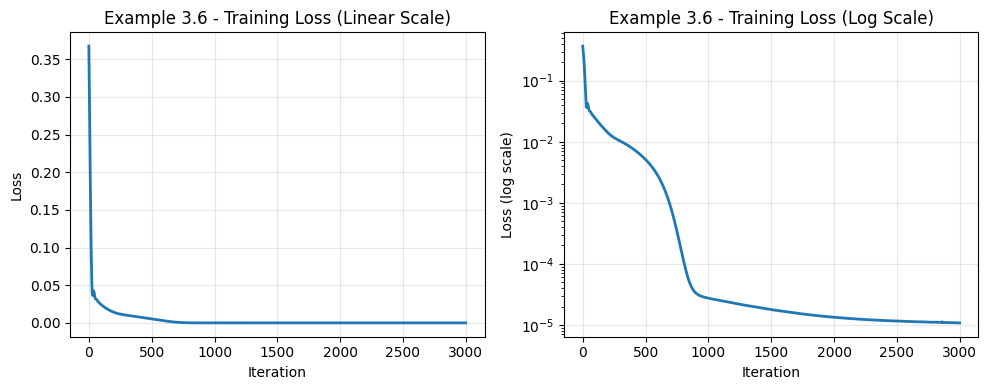

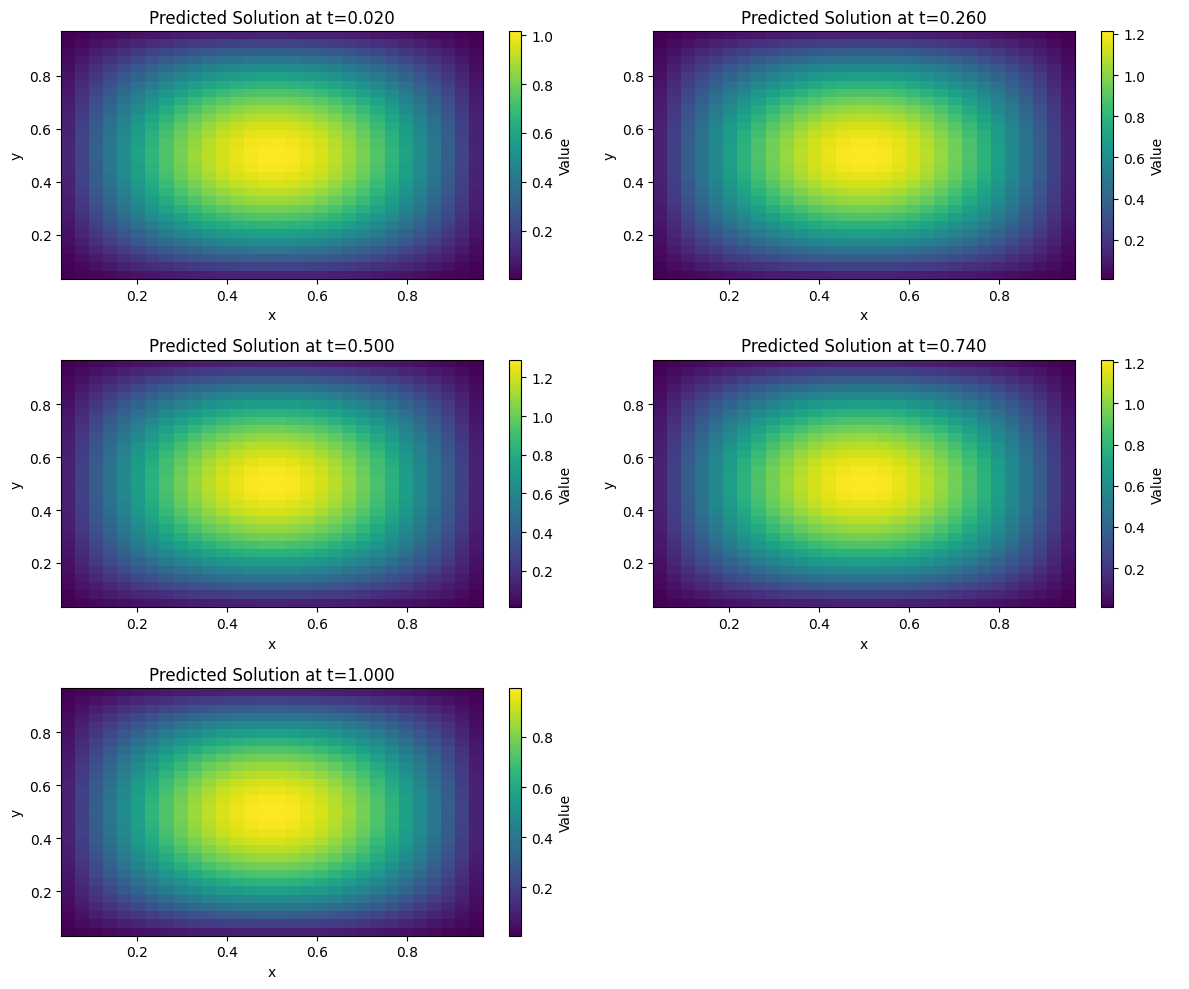

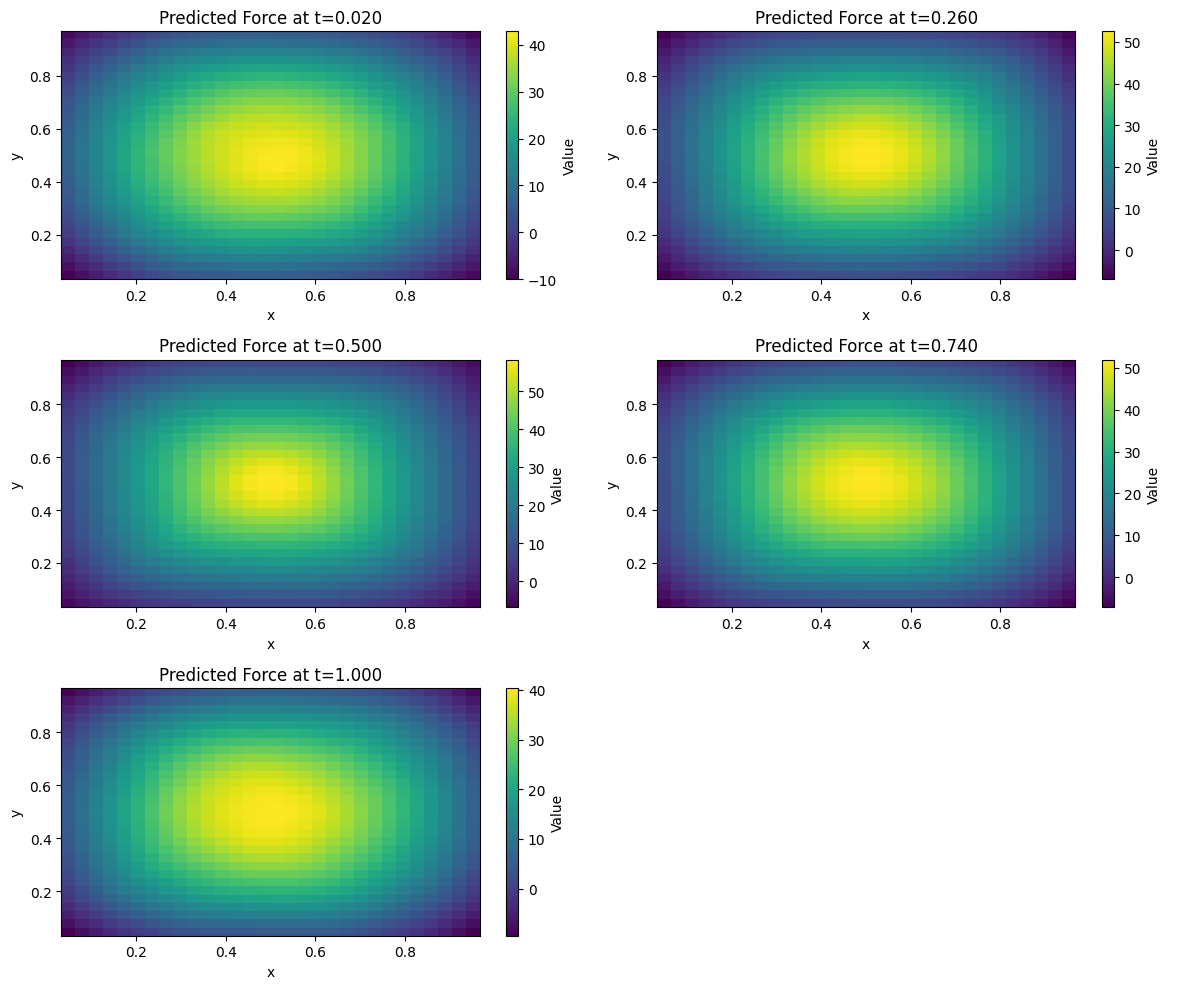

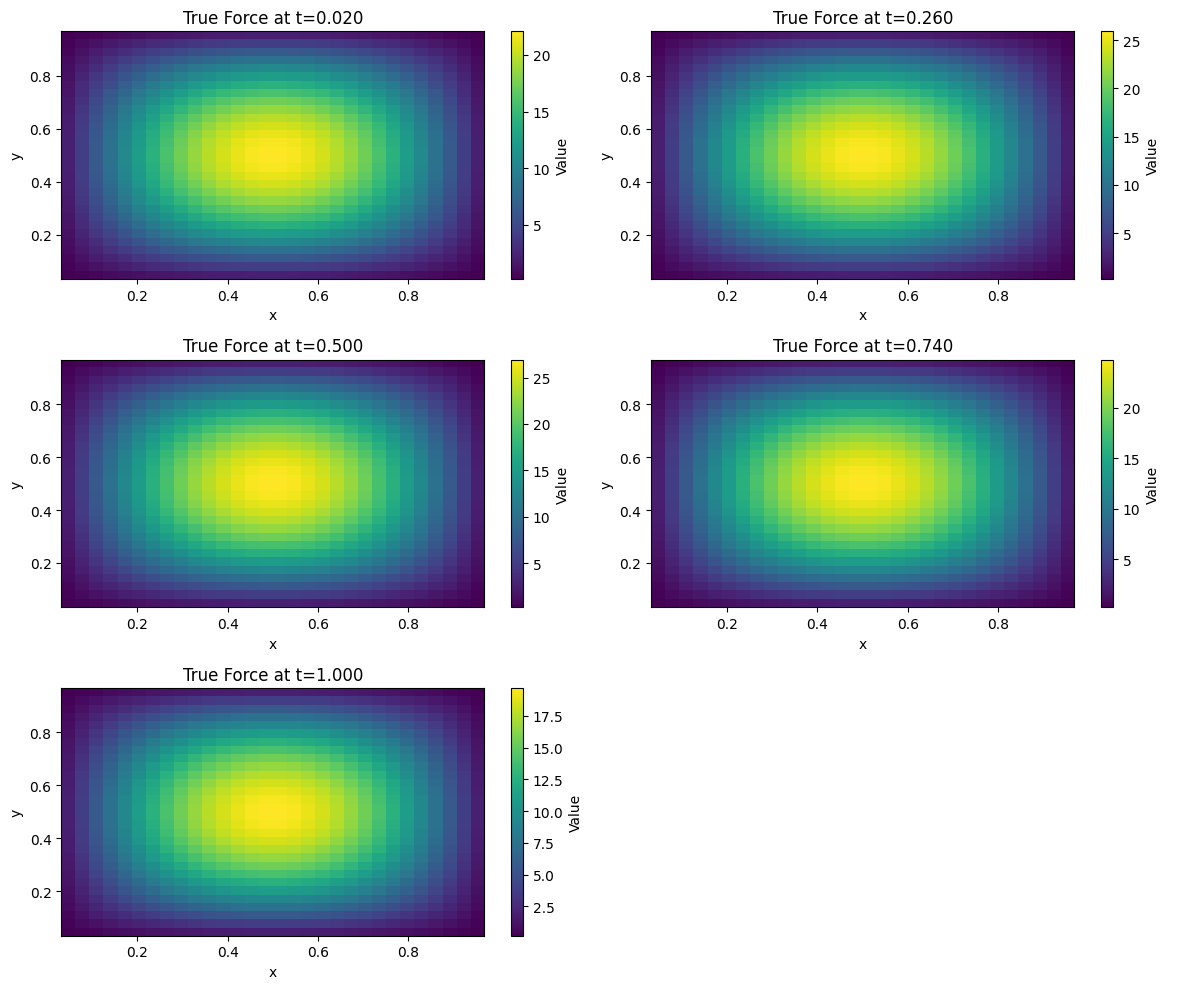

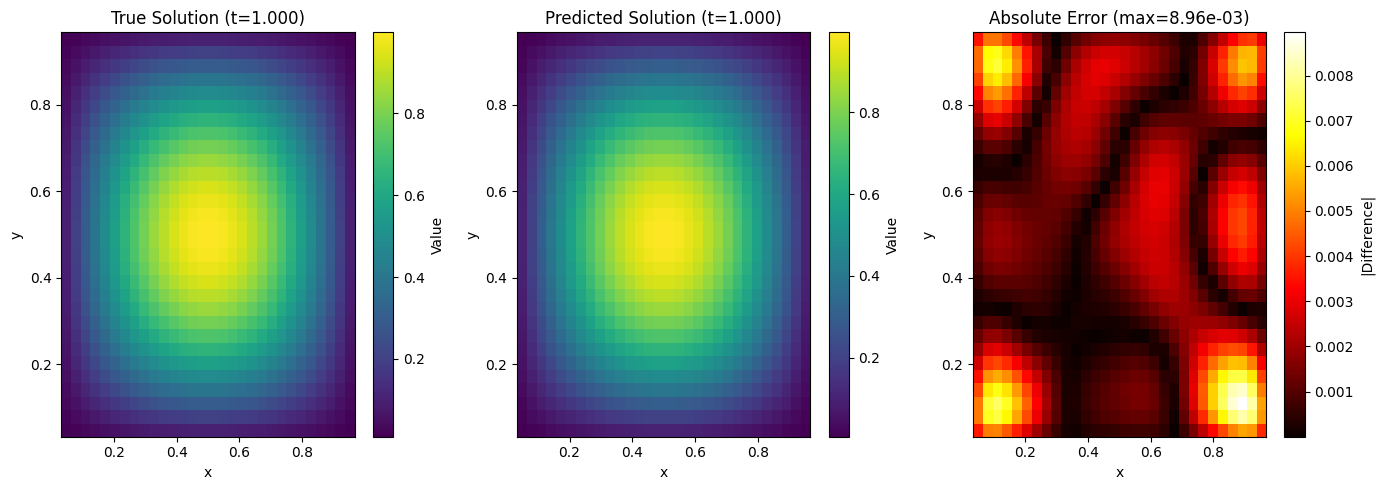

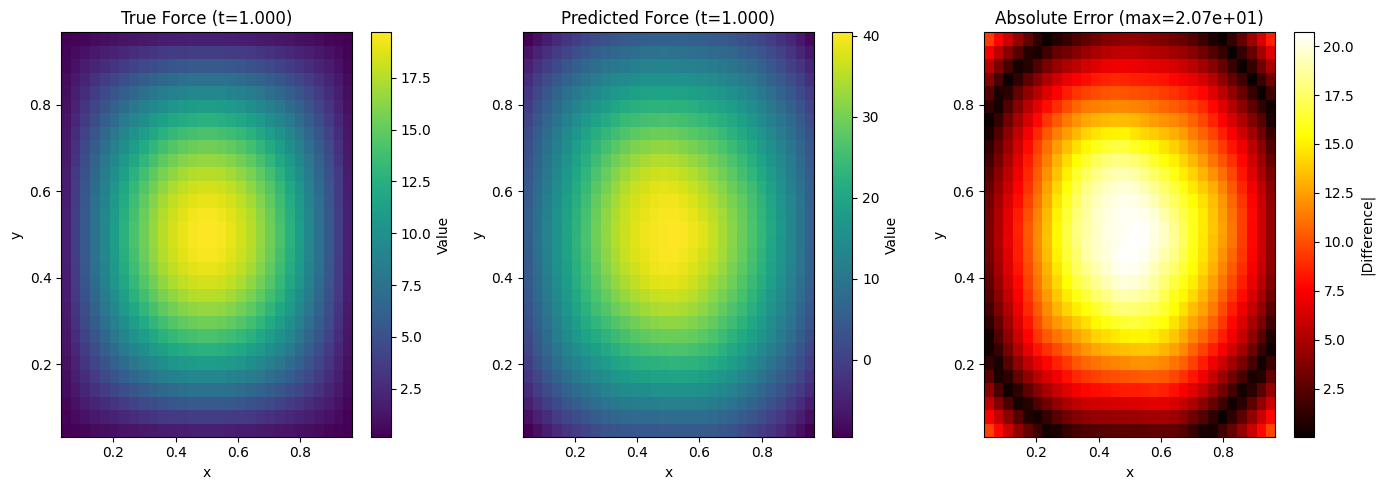


📊 Error Metrics:
  MSE:              4.382784e-06
  Relative L2:      3.411693e-03 (0.34%)
  Final loss:       1.078931e-05
  Initial loss:     3.674425e-01
  Loss reduction:   100.00%


In [7]:
# Unified plotting for all examples
print("\nGenerating plots...")
print("="*60)

# Get solver and problem for plotting
solver = get_solver(ex.solver_type, ex.discretization, **ex.grid_params)
# Pass all problem kwargs to ensure correct parameters (like n_oscillations)
if hasattr(ex, 'problem_kwargs'):
    problem = get_problem(ex.problem_name, **ex.problem_kwargs)
else:
    problem = get_problem(ex.problem_name)

# Plot results automatically based on example type
figures = plot_example_results(
    example_name=f"Example {CONFIG['example']}",
    solver=solver,
    problem=problem,
    params=params,
    losses=losses,
    force=force,
    solution=solution,
    max_snapshots=5,
    figsize_scale=1.0
)

plt.show()

# Print error metrics if applicable
if solution is not None and hasattr(solver, 't_grid'):
    # Time-dependent problem
    x_grid = solver.x_grid
    t_grid = solver.t_grid
    
    if hasattr(solver, 'y_grid'):
        # 2D spatial
        y_grid = solver.y_grid
        nx, ny, nt = solver.nx, solver.ny, solver.nt
        u_pred = solution.reshape(nx, ny, nt)
        u_true = jnp.stack([problem.analytical_solution(x_grid, y_grid, t) for t in t_grid], axis=-1)
    else:
        # 1D spatial
        nx, nt = solver.nx, solver.nt
        u_pred = solution.reshape(nx, nt)
        u_true = problem.analytical_solution(x_grid, t_grid)
    
    mse = jnp.mean((u_pred - u_true)**2)
    rel_err = jnp.linalg.norm(u_pred.flatten() - u_true.flatten()) / jnp.linalg.norm(u_true.flatten())
    
    print(f"\n📊 Error Metrics:")
    print(f"  MSE:              {mse:.6e}")
    print(f"  Relative L2:      {rel_err:.6e} ({100*rel_err:.2f}%)")
    print(f"  Final loss:       {losses[-1]:.6e}")
    print(f"  Initial loss:     {losses[0]:.6e}")
    print(f"  Loss reduction:   {100*(1 - losses[-1]/losses[0]):.2f}%")

print("="*60)

## Plot Results (Automatic Detection)